# Practice
## Cleaning and Decomposing Hourly Electricity Demand

### Scenario

You are working as a junior data analyst for an electricity utility.

You receive one year of **hourly electricity-demand data** measured in megawatts (MW).

The raw dataset may contain common time-series data-quality issues such as:

- timestamps stored in an unsuitable data type;
- observations that are not arranged chronologically;
- duplicated timestamps;
- missing demand observations.

Your task is to prepare the data and investigate its time-series structure.

---

### Main decomposition idea

For an additive decomposition:

$$
Y_t = T_t + S_t + R_t
$$

where:

- $Y_t$ = observed electricity demand;
- $T_t$ = trend;
- $S_t$ = seasonality;
- $R_t$ = residual.


## Learning objectives

By the end of this activity, you should be able to:

1. load and inspect hourly time-series data;
2. prepare a timestamp column;
3. check chronological ordering;
4. identify and handle duplicated timestamps;
5. identify and handle missing observations;
6. identify the observation frequency;
7. inspect and plot the observed time series;
8. investigate the time-of-day pattern;
9. decompose the series into trend, seasonality, and residual;
10. explain the main insight from each graph.


# Part A — Load and Inspect the Raw Data

## Task 1 — Import the required libraries

Import the libraries needed for:

- data handling;
- plotting;
- time-series decomposition.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

pd.set_option("display.max_columns", None)


## Task 2 — Load the dataset

Load the provided CSV file into a DataFrame and display several rows.


In [2]:
df_raw = pd.read_csv("cambodia_hourly_electricity_demand_practice.csv")
df_raw

,timestamp,electricity_demand_mw
0,2025-02-21 02:00:00,2007.5
1,2025-12-04 21:00:00,3195.9
2,2025-03-06 23:00:00,2802.9
3,2025-05-31 21:00:00,3615.9
4,2025-12-07 15:00:00,2887.6
...,...,...
8757,2025-08-27 22:00:00,3156.6
8758,2025-08-05 07:00:00,2436.8
8759,2025-08-13 14:00:00,3051.3
8760,2025-02-05 20:00:00,3373.3


### Record your observations

1. What are the columns? 
 - there are 2 columns 
2. Which column represents time?
 - the first columns represent time
3. Which column represents electricity demand?
 - the second column represents electricity demand
4. What does one row represent?
  - each row represent data time and electricity demand values
5. Do the timestamps appear to be ordered?
   - the timestamps isn't appear to be in ordered 


# Part B — Prepare the Time Column

## Task 3 — Inspect the DataFrame structure

Inspect:

- column data types;
- number of non-missing values;
- overall DataFrame structure.

**Hint — useful functions/attributes:**  
`dtypes` · `info()`


In [3]:
df_raw.dtypes

timestamp                 object
electricity_demand_mw    float64
dtype: object

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8762 entries, 0 to 8761
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              8762 non-null   object 
 1   electricity_demand_mw  8753 non-null   float64
dtypes: float64(1), object(1)
memory usage: 137.0+ KB


### Interpretation

Write your answers:

- Current timestamp data type: Object 
- Electricity-demand data type: float64
- Number of rows: 8,762
- Any missing values visible from the structure?
  - There are 9 missing values from the structure


## Task 4 — Convert the timestamp column to datetime

Convert the time column into an appropriate datetime representation.

Then check the data type again.

**Hint — useful functions:**  
`to_datetime()`


In [5]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], format='%Y-%m-%d %H:%M:%S')

# Part C — Check Chronological Order

## Task 5 — Check whether observations are ordered in time

Determine whether timestamps are already arranged from earliest to latest.

**Hint — useful attribute:**  
`is_monotonic_increasing`


In [6]:
df_raw['timestamp'].is_monotonic_increasing

False

### Question

Why could an unsorted time column produce a misleading line graph?

### Answer

A line graph joins consecutive rows in the order they appear in the DataFrame, not in the order of their timestamps. If the rows are unsorted, matplotlib draws a segment from, say, 21 February to 4 December and then back to 6 March, so the line jumps backwards and forwards across the year. The result is a dense zig-zag that hides the real trend and daily cycle, and it can make the series look far more volatile than it actually is. Sorting is also required before any operation that assumes time order — interpolation, `infer_freq()`, differencing, rolling windows, and decomposition.

## Task 6 — Sort the observations

Sort the DataFrame chronologically.

Then verify the ordering again.

**Hint — useful functions:**  
`sort_values()` · `reset_index()`


In [7]:
df_raw.sort_values(by='timestamp', inplace=True)
df_raw.reset_index()

,index,timestamp,electricity_demand_mw
0,1022,2025-01-01 00:00:00,2188.3
1,6781,2025-01-01 01:00:00,2053.2
2,7085,2025-01-01 02:00:00,1931.1
3,7865,2025-01-01 03:00:00,1994.7
4,8428,2025-01-01 04:00:00,1842.2
...,...,...,...
8757,158,2025-12-31 19:00:00,3419.9
8758,2219,2025-12-31 20:00:00,3558.4
8759,730,2025-12-31 21:00:00,3372.7
8760,712,2025-12-31 22:00:00,3143.9


# Part D — Check Duplicate Timestamps

## Task 7 — Identify duplicated timestamps

Find all rows whose timestamp appears more than once.

**Hint — useful functions:**  
`duplicated()`


In [8]:
df_raw['timestamp'].duplicated().sum()

np.int64(2)

### Interpretation

For each duplicate you find, think about:

- Could it be a repeated system export?
  - : repeated system export can be happened  due network retries (failed export mid-way) and manual override.
- Could it be a repeated measurement?
  - :  repeated measurement can be also happend due to merging error between old and new data.
- Could both records be valid?
  - : both records can be valid if we surveyed a user at exact same datetime and receiving the same inputs.
- Should duplicates be removed, summed, averaged, or investigated?
  - : at first we should investigated first whenether the input is come from the same user or not if it from different user we will perfrom group by /sum/ mean and will remove if we found out the input comming from the same user.

For this exercise, choose a reasonable approach and briefly justify it.


## Task 8 — Handle duplicated timestamps

Apply your chosen approach so that each timestamp appears only once.

Then verify the result.

**Hint — useful functions:**  
`groupby()` · `mean()` · `sum()` · `duplicated()`


In [9]:
df_raw = df_raw.groupby('timestamp', as_index=False).mean()

In [10]:
df_raw.duplicated().sum()

np.int64(0)

# Part E — Check Missing Values

## Task 9 — Count missing values

Check how many missing values exist in each column.

**Hint — useful functions:**  
`isna()` · `sum()`


In [11]:
df_raw.isna().sum()

timestamp                0
electricity_demand_mw    9
dtype: int64

## Task 10 — Display the missing observations

Show the rows where the electricity-demand measurement is missing.

**Hint — useful functions:**  
`isna()` · `loc`


In [12]:
df_raw.isna().loc[df_raw.isna().any(axis=1)]

,timestamp,electricity_demand_mw
412,False,True
902,False,True
1915,False,True
2963,False,True
3962,False,True
3963,False,True
5612,False,True
6801,False,True
8081,False,True


### Interpretation

Answer:

1. Does a missing electricity-demand value mean demand was zero?
 - : No, it doesn't it contain 9 missing Values.
2. What are some possible real-world reasons for a missing hourly measurement?
 - : in  a real world this can be system error from provider or  consumer failed to provided their daily usage data.


# Part F — Datetime Index and Interpolation

## Task 11 — Set the timestamp as the DataFrame index

Convert the timestamp column into the time index of the DataFrame.

**Hint — useful functions:**  
`set_index()`


In [13]:
df_raw.set_index('timestamp', inplace=True)

## Task 12 — Fill the missing demand observations

Use time-based interpolation to estimate the small gaps.

Afterward, confirm whether any missing values remain.

**Hint — useful functions:**  
`interpolate()` · `isna()` · `sum()`


In [14]:

df_raw.interpolate(method='time', inplace=True)
df_raw['electricity_demand_mw'].isna().sum()

np.int64(0)

### Reflection

Explain in your own words:

> Why is an interpolated value an estimate rather than a true observed value?

### Answer

An interpolated value is *constructed* from the neighbouring observations, not measured by the meter. `method='time'` draws a straight line between the last valid reading before the gap and the first valid reading after it, weighted by how far apart the timestamps are, and reads the missing hour off that line.

That estimate assumes demand moved smoothly and linearly across the gap. Real demand does not: within one hour it can spike from a heatwave, a large industrial load switching on, or a partial outage. Any of those events happened in the real series but cannot appear in the interpolated value, because the method only knows the two endpoints. So the filled value is a plausible placeholder that keeps the hourly grid complete (which STL requires), not evidence of what demand actually was. With only 9 gaps out of 8,760 hours (about 0.1%) the effect on the analysis is negligible, but the filled points should not be treated as observations.

# Part G — Check the Time Structure

## Task 13 — Inspect the time range and frequency

Determine:

- first timestamp;
- last timestamp;
- number of observations;
- inferred observation frequency.

**Hint — useful functions/attributes:**  
`min()` · `max()` · `len()` · `infer_freq()`


In [15]:
n_obs = len(df_raw)
freq = pd.infer_freq(df_raw.index)
print(f'first timestamp: {df_raw.index.min()}')
print(f'last timestamp: {df_raw.index.max()}')
print(f'number of observations: {len(df_raw)}')
print(f'frequency: {freq}')


first timestamp: 2025-01-01 00:00:00
last timestamp: 2025-12-31 23:00:00
number of observations: 8760
frequency: h


### Interpretation

1. What is the observation frequency?
2. How many observations correspond to one day?
3. How many observations correspond to one week?


### Answer
1. observation frequence is an hour.
2. observation correspond to one day is  24 hrs/day (24 hrs/day x 1hrs)
3. obervation correspond to one week is 168hrs ( 24hrs/day x 7days/week)


# Part H — Descriptive Statistics

## Task 14 — Summarize electricity demand

Generate descriptive statistics for the electricity-demand variable.

**Hint — useful functions:**  
`describe()`


In [16]:
df_raw['electricity_demand_mw'].describe()

count    8760.00000
mean     2772.63283
std       469.03197
min      1707.00000
25%      2343.10000
50%      2842.85000
75%      3119.75000
max      3897.10000
Name: electricity_demand_mw, dtype: float64

### Record the values

- Count: 8760.0
- Mean: 2772.63
- Standard deviation: 469.03
- Minimum: 1707.0
- 25th percentile: 2343.1
- Median: 2842.85
- 75th percentile: 3119.75
- Maximum: 3897.1

### Interpretation question

What can these statistics tell you, and what important time-related information do they **not** tell you?
The overall range of demand (min to max)
The typical/average level of demand (mean, median) across the whole year.
The spread/variability of demand (standard deviation, interquartile range).
Roughly how the values are distributed.
what important time-related information do they **not** tell me?
 - When any of these values occurred — you know the max was ~3,800 MW, but not which hour or day it happened.
 - Order or sequence — describe() treats every observation as if it were interchangeable; it has no sense of "before" and "after."
 - Patterns over time — no information about daily cycles (low at night, high in the evening), weekly patterns (weekday vs weekend), or seasonal/monthly trends across the year.
 - Trend direction — whether demand is generally rising, falling, or stable over the year.
 - Autocorrelation — whether high-demand hours tend to be followed by other high-demand hours (i.e., persistence in the series).


# Part I — Plot the Observed Time Series

## Task 15 — Plot the complete time series

Create a line graph showing electricity demand over the entire available period.

Include:

- a meaningful title;
- x-axis label;
- y-axis label.

**Hint — useful functions:**  
`figure()` · `plot()` · `title()` · `xlabel()` · `ylabel()` · `show()`


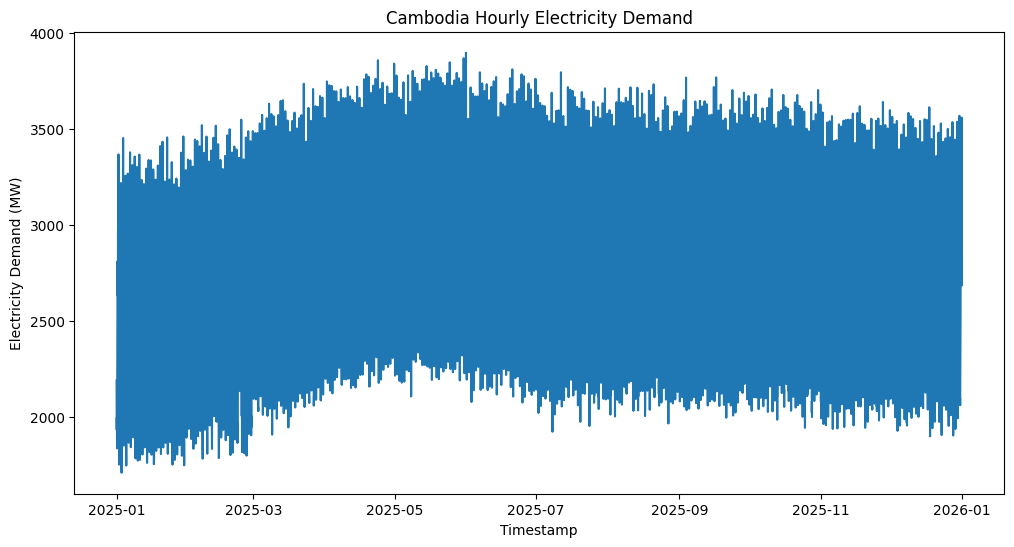

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_raw, x=df_raw.index, y='electricity_demand_mw')
plt.title('Cambodia Hourly Electricity Demand')
plt.xlabel('Timestamp')
plt.ylabel('Electricity Demand (MW)')
plt.show()

### Graph interpretation

Write at least **three observations** from the graph.

Consider:

- overall movement;
- repeated patterns;
- unusually high or low values;
- whether the graph is too dense to inspect short-term behavior.
### Answer

- Overall movement/trend: Electricity demand shows a mild seasonal rise-and-fall over the year — both the upper and lower bounds of demand climb gradually from January, peak somewhere around April–June, and then gradually decline back down toward December, ending near where it started in January.
- Repeated pattern (density): The plot looks like a solid, densely filled band rather than a clean line — this is because within each single day, demand swings repeatedly between a low band (~1,700–2,300 MW) and a high band (~3,000–3,900 MW). At this hourly resolution across a full year, thousands of daily up-and-down cycles are compressed into a few pixels, so they blur into a filled block instead of showing as distinct wiggles.
- Unusually high/low values: The highest peaks (~3,900 MW) occur around April–June, while the lowest troughs (~1,700 MW) occur in January — suggesting a seasonal effect (e.g., higher electricity use in hotter months, possibly for cooling). No dramatic one-off spikes or drops stand out beyond this seasonal band, which suggests no major anomalies remain after cleaning.
- Graph is too dense for short-term behavior: Because a full year of hourly data is compressed into one wide plot, it's impossible to see what a single day or week actually looks like — you can tell demand swings daily but not when within the day it rises or falls, or how weekdays compare to weekends. That's exactly the motivation for Task 16, where you zoom into a shorter window to inspect the daily cycle directly.

# Part J — Zoom In to Inspect the Daily Pattern

## Task 16 — Plot a shorter time window

Choose a short period that is long enough to show several complete daily cycles.

Create a line graph for that period.

**Hint — useful functions/methods:**  
`loc` · `figure()` · `plot()` · `show()`


In [18]:

df_window = df_raw.loc['2025-06-01 00:00:00':'2025-06-30 23:59:59'].reset_index()
df_window.head(50)

,timestamp,electricity_demand_mw
0,2025-06-01 00:00:00,2437.5
1,2025-06-01 01:00:00,2373.1
2,2025-06-01 02:00:00,2260.4
3,2025-06-01 03:00:00,2241.1
4,2025-06-01 04:00:00,2192.6
5,2025-06-01 05:00:00,2218.7
6,2025-06-01 06:00:00,2392.7
7,2025-06-01 07:00:00,2519.8
8,2025-06-01 08:00:00,2500.9
9,2025-06-01 09:00:00,2669.5


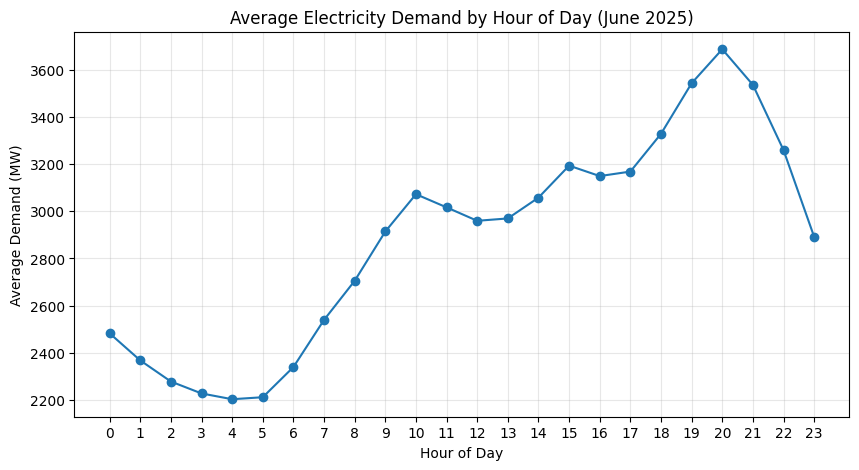

In [19]:
df_window = df_raw.loc['2025-06-01':'2025-06-30'].copy()
df_window['hour'] = df_window.index.hour

hourly_avg = df_window.groupby('hour')['electricity_demand_mw'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Electricity Demand by Hour of Day (June 2025)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

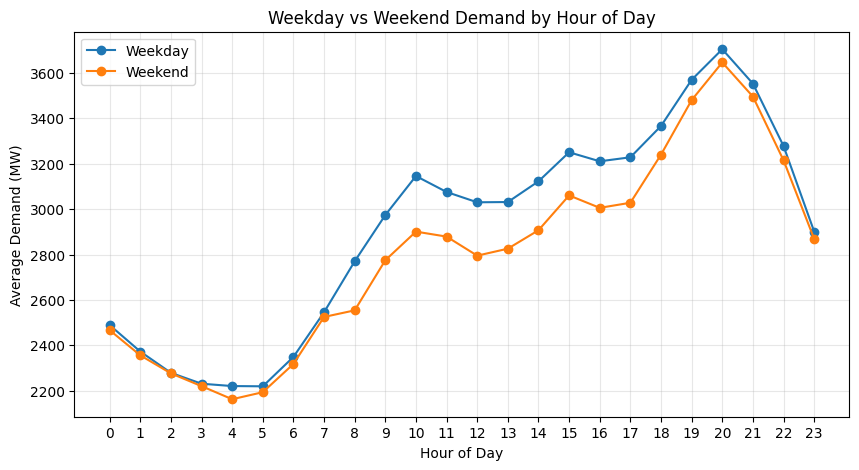

In [20]:
df_window['is_weekend'] = df_window.index.dayofweek >= 5

weekday_avg = df_window[~df_window['is_weekend']].groupby('hour')['electricity_demand_mw'].mean()
weekend_avg = df_window[df_window['is_weekend']].groupby('hour')['electricity_demand_mw'].mean()

plt.figure(figsize=(10, 5))
plt.plot(weekday_avg.index, weekday_avg.values, marker='o', label='Weekday')
plt.plot(weekend_avg.index, weekend_avg.values, marker='o', label='Weekend')
plt.title('Weekday vs Weekend Demand by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Graph interpretation

Look for:

- low-demand hours: around 12am–5am, demand stays near its lowest level (~1,800–2,000 MW), as most residential and commercial activity is inactive overnight.

- morning increase: demand starts climbing around 6am–8am, rising fairly sharply as people wake up, offices open, and daytime activity begins.

- daytime behavior: from roughly 9am–4pm, demand stays elevated and fairly stable (a plateau rather than a sharp peak), reflecting sustained commercial/industrial use and daytime cooling.

- evening behavior: demand reaches its highest point around 6pm–9pm, likely driven by people returning home, cooking, lighting, and continued cooling in the evening heat  then gradually declines overnight back toward the early-morning low.

- differences between weekdays and weekends: weekday and weekend curves follow a broadly similar daily shape (low overnight, peak in the evening), but at weekend the starting from 8am-16pm the graph slight dropped which is decreasing demand due to most of consumer might be spend time going outside at weekend to remove stress or relaxing

Write your observations without assuming that every day must look identical.


# Part K — Average Demand by Hour of Day

## Task 17 — Calculate average demand for each hour

Group all observations by **hour of day** and calculate the average electricity demand.

This is the one small extension from the earlier lesson, but it reuses the same grouping-and-average idea.

**Hint — useful functions/attributes:**  
`groupby()` · `mean()` · `index.hour`


In [21]:
df_hour_of_day = df_raw.groupby(df_raw.index.hour)['electricity_demand_mw'].mean()
df_hour_of_day 

timestamp
0     2368.595342
1     2262.653699
2     2184.016621
3     2127.343653
4     2086.740137
5     2117.672055
6     2230.743836
7     2422.367671
8     2583.267671
9     2811.738904
10    2975.526885
11    2922.567808
12    2844.792603
13    2871.463014
14    2959.968904
15    3079.340000
16    3032.847123
17    3066.267123
18    3217.590959
19    3451.606575
20    3575.267745
21    3429.438082
22    3136.204932
23    2785.166575
Name: electricity_demand_mw, dtype: float64

## Task 18 — Plot average demand by hour of day

Create a line graph of the 24 hourly averages.

**Hint — useful functions:**  
`figure()` · `plot()` · `xticks()` · `title()` · `xlabel()` · `ylabel()` · `show()`


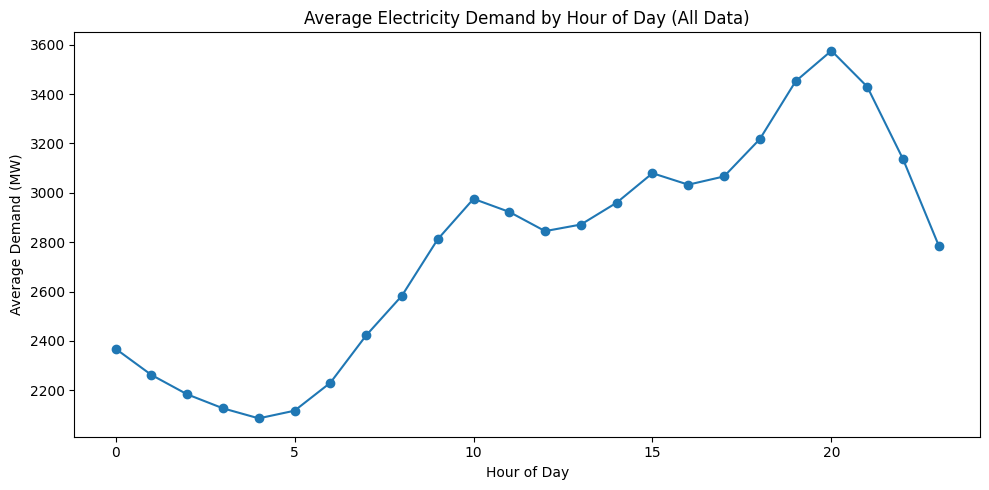

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(df_hour_of_day.index, df_hour_of_day.values, marker='o')
plt.title('Average Electricity Demand by Hour of Day (All Data)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.tight_layout()
plt.show()

### Graph interpretation

Answer:

1. Around what time is average demand lowest?
   - time when demand lowest is between 0 to 5am
2. When does demand begin increasing?
    - demand begin increasing from 5am to above.
3. Is there a daytime peak?
    - day time peak is at 10am.
4. Is there an evening peak?
    -  evening peak is at 8pm.
5. Which period appears to have the highest average electricity usage?
    - The evening hours (roughly 6pm–9pm) show the highest average electricity demand across the day. 
6. What real-life activities might explain this pattern?
    - likely because people return home from work/school, use lighting, cook dinner, and continue running air conditioning after a hot day  all overlapping in the same few hours and pushing demand to its daily maximum.


# Part L — Decompose the Time Series

## Task 19 — Choose an appropriate seasonal period

Before running decomposition, determine the seasonal period that represents one **daily cycle**.

Think about:

- the observation frequency;
- the number of observations in one day.

Write your chosen value and justify it.

**Hint — useful functions/classes:**  
`STL()` · `fit()`

### Chosen seasonal period: **`period = 24`**

**Justification.** The inferred frequency is hourly (`'h'`), so one observation = 1 hour and one complete day = 24 observations. The dominant repeating cycle in the data is the daily one (overnight trough → morning ramp → evening peak), which the hour-of-day plot in Task 18 confirmed. Setting `period=24` therefore tells STL to look for a pattern that repeats every 24 rows.

`robust=True` is used so that a few unusual hours (spikes or dips) do not distort the estimated seasonal shape.

*Note:* a weekly cycle (`period=168`) also exists in electricity data, but it is much weaker here — average demand is about 2,790–2,800 MW on Monday–Friday versus about 2,707–2,720 MW on Saturday/Sunday — so the daily cycle is the right choice for this single-period decomposition.

In [23]:
stl = STL(df_raw['electricity_demand_mw'], period=24, robust=True)
stl_result = stl.fit()

## Task 20 — Save the decomposition components

Create separate columns for:

- trend;
- seasonality;
- residual.

**Hint — useful attributes:**  
`trend` · `seasonal` · `resid`


In [24]:
df_raw['trend'] = stl_result.trend
df_raw['seasonal'] = stl_result.seasonal
df_raw['resid'] = stl_result.resid

df_raw.head()

,electricity_demand_mw,trend,seasonal,resid
timestamp,,,,
2025-01-01 00:00:00,2188.3,2570.230739,-395.416075,13.485337
2025-01-01 01:00:00,2053.2,2568.665767,-528.922641,13.456873
2025-01-01 02:00:00,1931.1,2567.110567,-624.190805,-11.819761
2025-01-01 03:00:00,1994.7,2565.564339,-860.214879,289.350540
2025-01-01 04:00:00,1842.2,2564.026466,-730.224253,8.397787


# Part M — Trend

## Task 21 — Plot the trend component

Create a line graph showing only the estimated trend.

**Hint — useful functions:**  
`figure()` · `plot()` · `title()` · `xlabel()` · `ylabel()` · `show()`


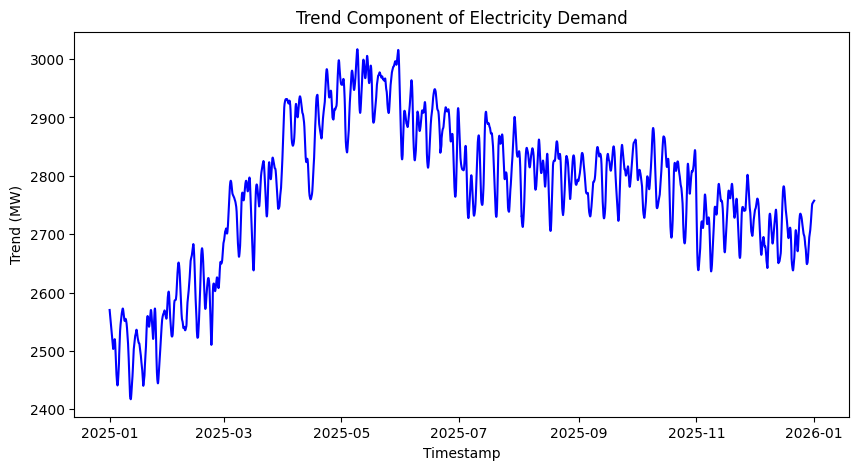

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(df_raw['trend'], label='Trend', color='blue')
plt.title('Trend Component of Electricity Demand')
plt.xlabel('Timestamp')
plt.ylabel('Trend (MW)')
plt.show()

### Graph interpretation

Explain:

1. Is the underlying demand level increasing, decreasing, or changing in another way?
2. Is the trend smoother than the observed series?
3. What does the trend tell you that the raw hourly graph did not show clearly?

### Answer

**1. Is the underlying demand level increasing, decreasing, or changing in another way?**
Neither purely increasing nor purely decreasing — it is **seasonal / hump-shaped**. The trend starts near 2,570 MW in early January, dips to its yearly minimum of about 2,417 MW on 11 January, then climbs steadily to a peak of roughly 3,017 MW on 9 May, and afterwards drifts down through the second half of the year to about 2,757 MW at the end of December. Monthly averages of the trend tell the same story: about 2,518 MW in January, rising to about 2,954 MW in May, then easing back to about 2,704 MW in December. This matches Cambodia's climate — the hot season (March–May) drives cooling load, and demand relaxes through the wet season and into the cooler months.

**2. Is the trend smoother than the observed series?**
Yes, dramatically. The observed series has a standard deviation of about 469 MW, while the trend component has a standard deviation of only about 126 MW. STL has stripped out the ±800 MW daily swing, so what remains is a slow-moving curve with no visible hourly wiggle.

**3. What does the trend tell you that the raw hourly graph did not show clearly?**
The raw plot was a solid band of ink — the daily cycle repeated 365 times drowned out everything else, so the only thing visible was roughly where the band sat. The trend isolates the **underlying level** of demand: it shows the size of the seasonal build-up (about 600 MW, or roughly 25%, from the January low to the May peak), pinpoints *when* the peak occurs (early May, not mid-year), and shows that the decline afterwards is gradual rather than a sudden drop. It also shows the year does not end where it began — December sits well above January, which is useful for anyone forecasting into the next year.

# Part N — Seasonality

## Task 22 — Plot the seasonal component

Choose a short period that makes the repeated daily seasonal pattern easy to inspect.

**Hint — useful functions/methods:**  
`loc` · `figure()` · `plot()` · `axhline()` · `show()`


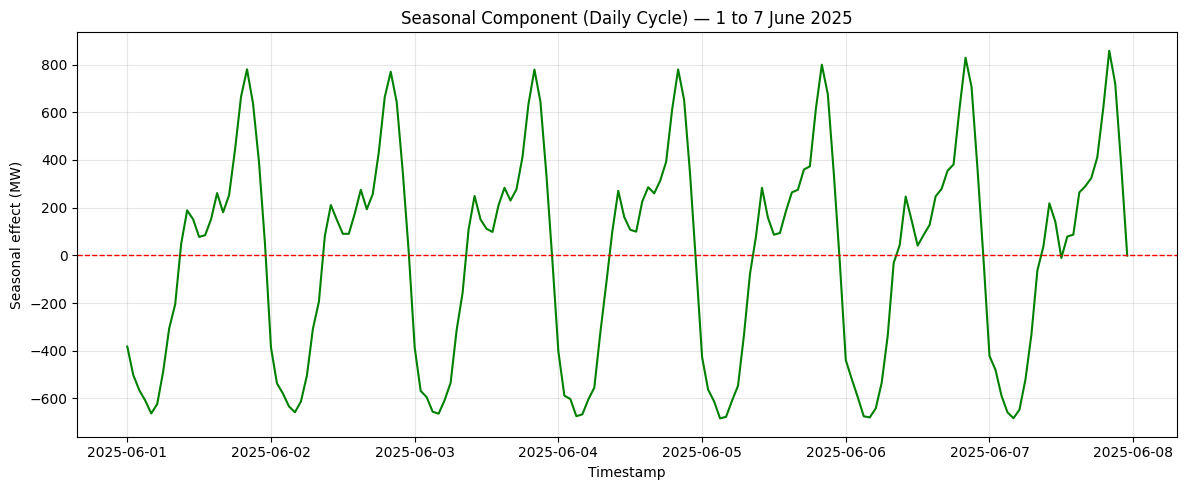

timestamp
0    -408.6
1    -512.8
2    -589.4
3    -648.3
4    -689.2
5    -655.3
6    -543.7
7    -352.8
8    -187.7
9      44.7
10    207.4
11    149.7
12     67.1
13    102.2
14    186.4
15    307.0
16    263.0
17    298.5
18    447.5
19    678.9
20    800.8
21    658.0
22    364.0
23     12.4
Name: seasonal, dtype: float64


In [ ]:

seasonal_window = df_raw.loc['2025-06-01':'2025-06-07', 'seasonal']

plt.figure(figsize=(12, 5))
plt.plot(seasonal_window.index, seasonal_window.values, color='green')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Seasonal Component (Daily Cycle) — 1 to 7 June 2025')
plt.xlabel('Timestamp')
plt.ylabel('Seasonal effect (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


seasonal_by_hour = df_raw.groupby(df_raw.index.hour)['seasonal'].mean().round(1)
print(seasonal_by_hour)

### Graph interpretation

Answer:

1. Does the pattern repeat?
2. How often does it repeat?
3. During which hours is the seasonal effect generally positive?
4. During which hours is it generally negative?
5. What does a positive seasonal value mean?
6. What does a negative seasonal value mean?

### Answer

**1. Does the pattern repeat?**
Yes. The seasonal component is an almost perfectly regular wave — seven near-identical cycles appear in the 1–7 June window, with the same shape each day.

**2. How often does it repeat?**
Every **24 observations = 24 hours = one day**, which is exactly the period given to STL. The shape drifts only very slightly across the year (the 20:00 effect is about +803 MW in January and about +792 MW in December), because STL allows the seasonal pattern to evolve slowly rather than forcing it to be identical.

**3. During which hours is the seasonal effect generally positive?**
Roughly **09:00 to 23:00**. Averaged over the year the effect turns positive at 09:00 (about +45 MW), stays high through the afternoon (about +186 MW at 14:00, +307 MW at 15:00), and reaches its maximum at **20:00 (about +801 MW)**, with 19:00 (+679 MW) and 21:00 (+658 MW) close behind. By 23:00 it is back to about +12 MW, essentially zero.

**4. During which hours is it generally negative?**
Roughly **00:00 to 08:00**. The effect is about −409 MW at midnight and reaches its deepest point at **04:00 (about −689 MW)** before recovering through the morning (about −188 MW at 08:00).

**5. What does a positive seasonal value mean?**
That this hour of the day is *typically busier than the day's underlying level*. At 20:00 demand normally sits roughly 800 MW **above** the trend, purely because of what time it is.

**6. What does a negative seasonal value mean?**
That this hour is *typically quieter than the underlying level*. At 04:00 demand normally sits roughly 690 MW **below** the trend. The peak-to-trough spread of the daily cycle is therefore about 1,490 MW — larger than the entire seasonal swing of the trend across the year, which is why the daily cycle dominates the raw plot.

# Part O — Residual

## Task 23 — Plot the residual component

Create a residual line graph and include a horizontal reference line at zero.

**Hint — useful functions:**  
`figure()` · `plot()` · `axhline()` · `show()`


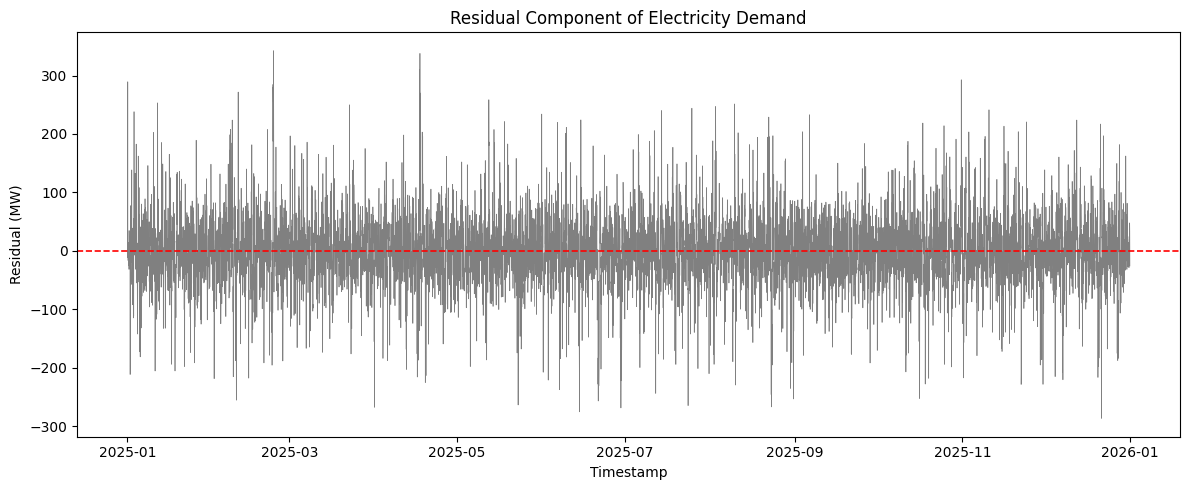

count    8760.00
mean       -0.30
std        59.51
min      -286.85
25%       -31.73
50%         0.04
75%        30.84
max       342.58
Name: resid, dtype: float64

Largest residuals:
                     electricity_demand_mw   trend  seasonal  resid
timestamp                                                          
2025-02-23 04:00:00                 2143.7  2548.3    -747.2  342.6
2025-04-17 12:00:00                 3091.8  2885.2    -131.3  338.0
2025-04-17 08:00:00                 2891.8  2873.3    -292.3  310.8
2025-02-23 05:00:00                 2177.3  2554.3    -680.6  303.7
2025-10-31 14:00:00                 3225.3  2819.6     112.9  292.8


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_raw.index, df_raw['resid'], linewidth=0.5, color='grey')
plt.axhline(0, color='red', linestyle='--', linewidth=1.2)
plt.title('Residual Component of Electricity Demand')
plt.xlabel('Timestamp')
plt.ylabel('Residual (MW)')
plt.tight_layout()
plt.show()

print(df_raw['resid'].describe().round(2))

largest = df_raw['resid'].abs().nlargest(5).index
print('\nLargest residuals:')
print(df_raw.loc[largest, ['electricity_demand_mw', 'trend', 'seasonal', 'resid']].round(1))

### Graph interpretation

Answer:

1. Do residuals fluctuate around zero?
2. Do they show the same obvious daily repetition as the seasonal component?
3. Are there unusually large residuals?
4. What real-world situations could produce a large residual?

### Answer

**1. Do residuals fluctuate around zero?**
Yes. The mean residual is about **−0.3 MW** — effectively zero — with a standard deviation of about **59.5 MW**. The plot is a flat, evenly spread band centred on the red zero line, with no visible drift up or down over the year. That is what a good decomposition should look like: the trend and seasonal components have absorbed the structure, leaving noise behind.

**2. Do they show the same obvious daily repetition as the seasonal component?**
No. The residual plot has no visible wave. Any regular 24-hour pattern has been captured by the seasonal component, which is exactly why `period=24` was the right choice. There is only a faint weekday/weekend hint left over — average residuals are about +14 MW on Monday and Friday versus about −22 MW on Saturday — because the model was given a daily period, not a weekly one.

**3. Are there unusually large residuals?**
A few. About 95% of residuals lie within ±2 standard deviations (roughly ±119 MW), and the extremes are about **+343 MW (23 February, 04:00)** and **−287 MW (21 December, 14:00)**. The 23 February case is an overnight hour where actual demand of 2,143.7 MW came in far above what a trend of 2,548.3 MW plus a seasonal effect of −747.2 MW predicted, so something kept load high that night. These are noticeable but not extreme relative to a series that averages about 2,773 MW — each is roughly 10% of the mean.

**4. What real-world situations could produce a large residual?**
- Weather that departs from the seasonal norm — an unusually hot night, or a cool cloudy day that suppresses air-conditioning load.
- Public holidays and festivals (Khmer New Year, Pchum Ben, Water Festival), when businesses close and the normal weekday shape does not apply.
- A large industrial customer starting or stopping an unusual shift.
- Supply-side events: a generation or transmission outage, or load shedding, which caps demand below what customers wanted.
- Measurement and data issues — a meter fault, a delayed export, or one of the 9 interpolated hours, where the filled straight-line value does not match what actually happened.

**Variance check:** the seasonal component accounts for about 91% of the variance in the observed series, the trend about 7%, and the residual only about 2% — so the model explains the great majority of the movement in demand.

# Part P — Compare All Components

## Task 24 — Plot all components together

Create four vertically aligned plots:

1. observed demand;
2. trend;
3. seasonality;
4. residual.

**Hint — useful functions:**  
`subplots()` · `plot()` · `set_title()` · `axhline()` · `tight_layout()` · `show()`


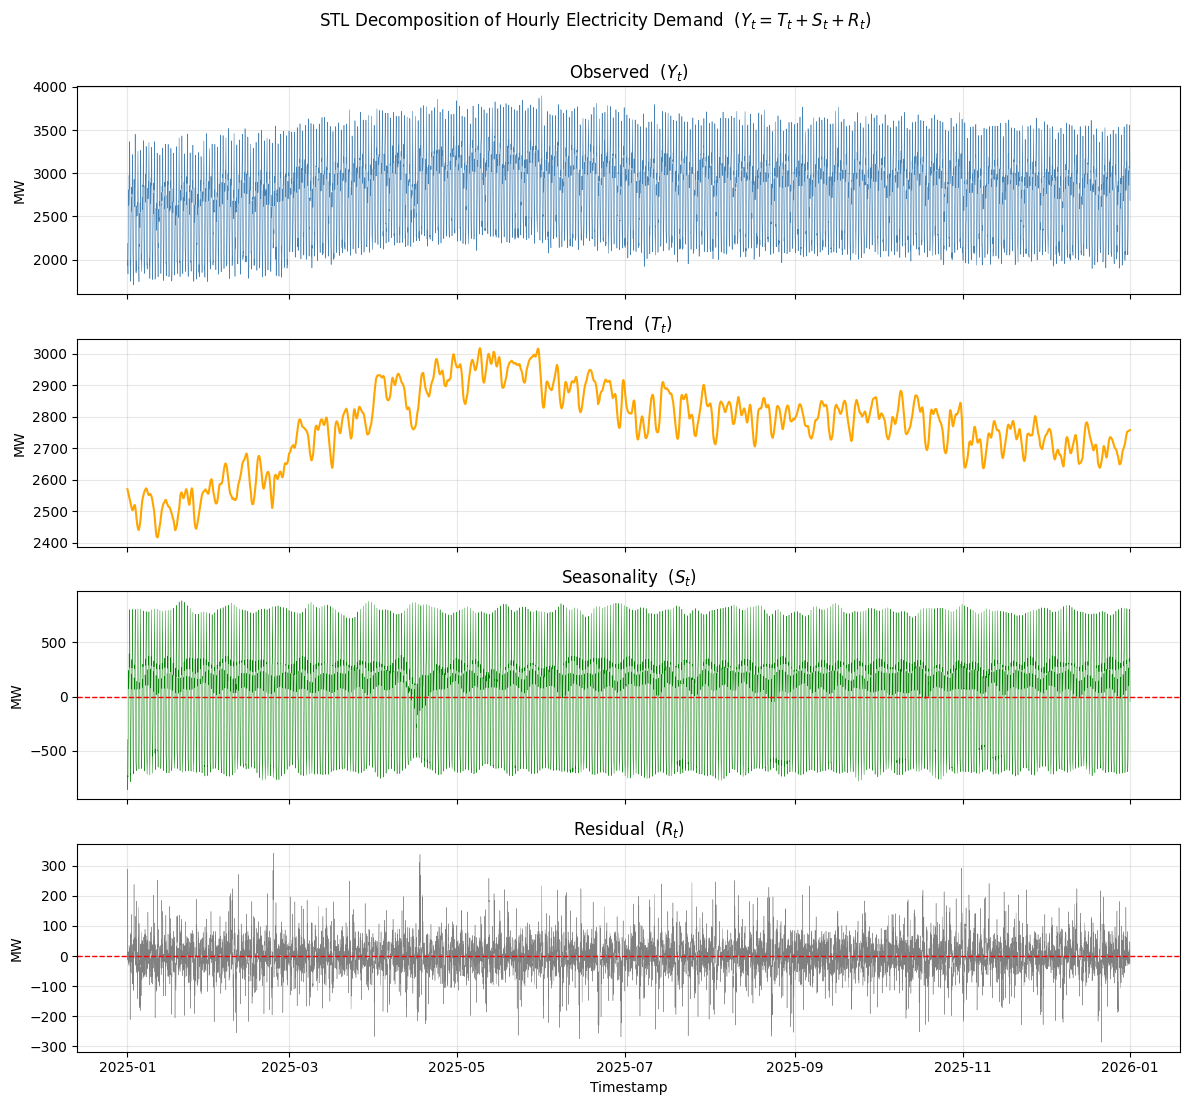

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(df_raw.index, df_raw['electricity_demand_mw'], linewidth=0.4, color='steelblue')
axes[0].set_title('Observed  ($Y_t$)')
axes[0].set_ylabel('MW')

axes[1].plot(df_raw.index, df_raw['trend'], color='orange', linewidth=1.5)
axes[1].set_title('Trend  ($T_t$)')
axes[1].set_ylabel('MW')

axes[2].plot(df_raw.index, df_raw['seasonal'], linewidth=0.3, color='green')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Seasonality  ($S_t$)')
axes[2].set_ylabel('MW')

axes[3].plot(df_raw.index, df_raw['resid'], linewidth=0.3, color='grey')
axes[3].axhline(0, color='red', linestyle='--', linewidth=1)
axes[3].set_title('Residual  ($R_t$)')
axes[3].set_ylabel('MW')
axes[3].set_xlabel('Timestamp')

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle('STL Decomposition of Hourly Electricity Demand  ($Y_t = T_t + S_t + R_t$)', y=1.00)
plt.tight_layout()
plt.show()

### Interpretation

Use the relationship:

$$
Y_t = T_t + S_t + R_t
$$

Explain how the four graphs tell one connected story.

Write at least one sentence for each:

- Observed:
- Trend:
- Seasonality:
- Residual:

### Answer

**Observed ($Y_t$):** The top panel is the full record of what the meters actually measured — a dense band ranging from 1,707 MW to 3,897 MW, in which the year-long seasonal drift and the 365 daily cycles are stacked on top of each other and impossible to separate by eye. Everything in the three panels below adds back up to exactly this line.

**Trend ($T_t$):** The second panel answers *"what is the underlying level of demand right now?"* Stripped of the daily cycle, demand rises from about 2,417 MW in mid-January to about 3,017 MW in early May, then eases back to about 2,757 MW by December — a slow, weather-driven build-up and release worth roughly 600 MW, which is the part of the story an electricity planner would use for capacity decisions.

**Seasonality ($S_t$):** The third panel answers *"how does the time of day move demand away from that level?"* It is a fixed-shape daily wave running from about −689 MW at 04:00 to about +801 MW at 20:00, repeating every 24 hours all year. It contributes about 91% of the variance in the observed series — it is the reason the top panel looks like a solid block rather than a line.

**Residual ($R_t$):** The bottom panel is what is left once level and time-of-day are accounted for: a flat band of noise centred on zero (mean about −0.3 MW, standard deviation about 59.5 MW) with no repeating structure, plus a handful of one-off events reaching about ±340 MW. Because it is small and patternless, it confirms the decomposition worked — the trend and the daily cycle really are the two forces driving this series.

**The connected story:** demand on any given hour = the season's underlying level (trend) + the usual effect of that hour of the day (seasonality) + whatever was unusual about that particular hour (residual). For example, at 06:00 on 1 June 2025 the observed 2,392.7 MW = a trend of 2,834.3 MW + a seasonal effect of −486.7 MW + a residual of +45.1 MW.

# Part Q — Verify the Components Numerically

## Task 25 — Build a component table

Create a table containing:

- observed electricity demand;
- trend;
- seasonality;
- residual.

Display a short period containing several hourly observations.

**Hint — useful functions/methods:**  
`loc` · `round()`


In [ ]:
components = df_raw.loc[
    '2025-06-01 00:00:00':'2025-06-01 11:00:00',
    ['electricity_demand_mw', 'trend', 'seasonal', 'resid']
].round(1)


components['T + S + R'] = (
    components['trend'] + components['seasonal'] + components['resid']
).round(1)

components

,electricity_demand_mw,trend,seasonal,resid,T + S + R
timestamp,,,,,
2025-06-01 00:00:00,2437.5,2854.5,-382.3,-34.7,2437.5
2025-06-01 01:00:00,2373.1,2850.2,-501.4,24.3,2373.1
2025-06-01 02:00:00,2260.4,2846.1,-564.8,-20.9,2260.4
2025-06-01 03:00:00,2241.1,2842.5,-608.6,7.2,2241.1
2025-06-01 04:00:00,2192.6,2839.3,-662.7,16.0,2192.6
2025-06-01 05:00:00,2218.7,2836.6,-623.5,5.6,2218.7
2025-06-01 06:00:00,2392.7,2834.3,-486.7,45.1,2392.7
2025-06-01 07:00:00,2519.8,2832.4,-306.0,-6.6,2519.8
2025-06-01 08:00:00,2500.9,2830.9,-205.4,-124.6,2500.9


### Manual check

Choose one row from your table and verify:

$$
\text{Observed}
\approx
\text{Trend}
+
\text{Seasonality}
+
\text{Residual}
$$

Record your calculation below.

### Calculation

Row chosen: **2025-06-01 06:00:00**

| Component | Value (MW) |
|---|---|
| Trend $T_t$ | 2,834.3 |
| Seasonality $S_t$ | −486.7 |
| Residual $R_t$ | +45.1 |
| **Sum $T_t + S_t + R_t$** | **2,392.7** |
| Observed $Y_t$ | 2,392.7 |

$$2{,}834.3 + (-486.7) + 45.1 = 2{,}392.7 = Y_t \quad \checkmark$$

The identity holds exactly (any tiny difference is rounding to 1 decimal place), which confirms the decomposition is **additive**: STL splits the observed value into three parts that add back to the original with nothing lost.

Reading the row in words: at 06:00 the underlying level of demand for early June was about 2,834 MW, being 6am pulled it down by about 487 MW because most people and businesses were not yet active, and this particular morning ran about 45 MW busier than a typical 6am — giving the 2,392.7 MW actually recorded.

# Part R — Main Achievement Challenge

## Task 26 — Compare selected hours

Using your hourly-average result, compare average electricity demand at:

- 03:00;
- 10:00;
- 20:00.

Then explain which is highest and why that pattern is reasonable.

**Hint — useful functions/methods:**  
`groupby()` · `mean()` · `loc`


In [30]:
selected_hours = df_hour_of_day.loc[[3, 10, 20]].round(1)
print('Average demand at selected hours (MW):')
print(selected_hours)

highest = selected_hours.idxmax()
print(f'\nHighest: {highest:02d}:00 at {selected_hours.max():.1f} MW')
print(f'20:00 exceeds 03:00 by {selected_hours.loc[20] - selected_hours.loc[3]:.1f} MW '
      f'({(selected_hours.loc[20] / selected_hours.loc[3] - 1) * 100:.1f}%)')


Average demand at selected hours (MW):
timestamp
3     2127.3
10    2975.5
20    3575.3
Name: electricity_demand_mw, dtype: float64

Highest: 20:00 at 3575.3 MW
20:00 exceeds 03:00 by 1448.0 MW (68.1%)


### Explanation

| Hour | Average demand |
|---|---|
| 03:00 | 2,127.3 MW |
| 10:00 | 2,975.5 MW |
| 20:00 | **3,575.3 MW** |

**20:00 is the highest**, exceeding 03:00 by 1,448.0 MW — about **68% higher**. 10:00 sits in between, closer to the daily average of about 2,773 MW.

This ordering is exactly what the daily cycle predicts, and it is reasonable in real terms:

- **03:00** is the deepest part of the overnight trough. Households are asleep, offices and shops are closed, and only base load — street lighting, refrigeration, continuous industrial processes, telecom equipment — is running.
- **10:00** is mid-morning: offices, schools, markets and factories are all active, and daytime cooling has started. This is the local daytime peak, but commercial load alone does not push demand to its maximum.
- **20:00** is the evening peak, when residential and commercial demand *overlap*. People are home cooking, lighting, watching TV and running air conditioning against the heat retained from the day, while shops, restaurants and street lighting are still drawing power. Two large loads stacking at the same hour is what makes 20:00 the daily maximum — and it is why the yearly maximum of 3,897.1 MW also fell at 20:00 (on 31 May 2025).

# Optional Challenge — Extreme Timestamps

This challenge is optional because it introduces two additional methods that are **not required for the core lesson**.

Try to find:

1. the timestamp with the highest electricity demand;
2. the timestamp with the lowest electricity demand.

**Optional hints:**  
`idxmax()` · `idxmin()`

After finding them, explain whether the times make sense based on the daily demand pattern you discovered.


In [31]:
max_ts = df_raw['electricity_demand_mw'].idxmax()
min_ts = df_raw['electricity_demand_mw'].idxmin()

print(f'Highest demand: {df_raw["electricity_demand_mw"].max():.1f} MW '
      f'at {max_ts} ({max_ts.day_name()})')
print(f'Lowest demand:  {df_raw["electricity_demand_mw"].min():.1f} MW '
      f'at {min_ts} ({min_ts.day_name()})')

Highest demand: 3897.1 MW at 2025-05-31 20:00:00 (Saturday)
Lowest demand:  1707.0 MW at 2025-01-03 04:00:00 (Friday)


### Answer

- **Highest:** 3,897.1 MW on **Saturday 31 May 2025 at 20:00**
- **Lowest:** 1,707.0 MW on **Friday 3 January 2025 at 04:00**

Both make sense, and each is explained by the trend and the seasonal component landing at their extremes at the same moment:

- The maximum falls at **20:00**, the exact hour with the largest positive seasonal effect (about +801 MW), and at the end of May, when the trend is near its yearly high of about 3,017 MW (hot-season cooling load). Peak hour of the day meets peak season of the year.
- The minimum falls at **04:00**, the hour with the deepest negative seasonal effect (about −689 MW), and in early January, when the trend is at its yearly low of about 2,417 MW. Trough hour meets trough season.

Neither is an anomaly, then — both are the predictable consequence of the two components lining up, which is a further sign that the decomposition captured the structure of the series correctly.

# Final Takeaway

You started with a messy operational-looking dataset and completed:

$$
\boxed{
\text{Load}
\rightarrow
\text{Convert Time}
\rightarrow
\text{Sort}
\rightarrow
\text{Handle Duplicates}
\rightarrow
\text{Interpolate Missing Values}
}
$$

Then you investigated:

$$
\boxed{
\text{Observed Demand}
=
\text{Trend}
+
\text{Daily Seasonality}
+
\text{Residual}
}
$$

The important achievement is not just that the code ran.

You should now be able to connect the graph to a real operational story:

> **Electricity demand changes according to when people and businesses use electricity.**
 

### Final questions

1. Which step in the cleaning process was most important to you, and why?
2. Which graph gave you the clearest insight into electricity-demand behavior?
3. What did decomposition reveal that the original line graph did not?
4. What would you want to investigate next before building a forecasting model?

### Answers

**1. Which step in the cleaning process was most important to you, and why?**
**Sorting the timestamps.** The raw file arrived in essentially random order, and every later step silently assumed chronological order — time-based interpolation needs to know which observations are neighbours, `infer_freq()` needs an ordered index to detect the hourly spacing, and STL assumes consecutive rows are consecutive hours. Skipping the sort would not have produced an error; it would have produced confident, meaningless output, which is worse. Handling the 2 duplicate timestamps was a close second, because they were what broke the count of 8,762 rows away from the 8,760 hours in the year, and STL needs a complete, gap-free hourly grid.

**2. Which graph gave you the clearest insight into electricity-demand behaviour?**
The **average-demand-by-hour-of-day plot** (Task 18). The full-year raw plot was too dense to read, but averaging over all 365 days collapsed the noise and made the operational story immediately visible: an overnight floor around 2,087 MW at 04:00, a morning ramp from about 06:00, a daytime plateau, and a sharp evening peak of 3,575 MW at 20:00.

**3. What did decomposition reveal that the original line graph did not?**
It separated two effects that the raw plot had fused into a single black band. The trend showed a seasonal build-up of roughly 600 MW from the January low to the early-May peak, which was invisible before because the daily swing was three times larger. The seasonal component quantified that daily swing precisely — from about −689 MW at 04:00 to about +801 MW at 20:00. And the residual showed that once those two are removed, only about 2% of the variance is left as noise, meaning almost everything in the series is explained by *time of year* and *time of day*.

**4. What would you want to investigate next before building a forecasting model?**
- **A weekly seasonality term.** Weekends already average about 80–90 MW lower than weekdays and that pattern is still sitting in the residuals; an MSTL decomposition with periods of both 24 and 168 would capture it.
- **Holiday effects.** Khmer New Year, Pchum Ben and Water Festival are likely behind some of the largest residuals and should be flagged as explicit calendar features.
- **Weather data.** Temperature and humidity almost certainly drive the trend hump; adding them as external regressors would probably explain more than a purely date-based model can.
- **Stationarity and autocorrelation.** ACF/PACF plots and an ADF test on the residuals, to confirm there is no leftover structure and to choose sensible lag features.
- **A proper train/test split by time** (for example, train on January–October and test on November–December), plus a naïve seasonal baseline to beat, so any model's accuracy can be judged honestly.
- **The 9 interpolated hours** should be excluded from evaluation, since they are estimates rather than observations.